In [1]:
import pandas as pd 
import numpy as np 
import scipy 
import statsmodels.api as sm 
import matplotlib.pyplot as plt 
import seaborn as sns
import yfinance as yf

In [2]:
import sys
from datetime import date
sys.path.append('../src')
from data_utils import load_ohlcv, check_missing_prices, check_missing_volumes, check_duplicates, check_invalid_dates, check_zero_prices, check_extreme_returns, check_volume_spikes
from data_utils import compute_returns, aggregate_returns, performance_summary, build_value_weight_portfolio, build_equal_weight_portfolio, rolling_stats, build_value_weight_portfolio_historic
# df = load_ohlcv(["AAPL", "MSFT"], start="2021-01-01", end=str(date.today()))
from data_utils import load_ohlcv
tickers = [
    "NVDA", "META", "GOOGL", "MSFT", "TSLA", "ORCL", "AMD", "INTC", "SMCI", "MU",
    "RKLB", "WDC", "STX", "CRWD", "PLTR",
    "AAPL", "AMZN", "AVGO", "CSCO", "ADBE", "CRM", "NFLX", "QCOM", "TXN", "TSM",
    "JPM", "BAC", "WFC", "V", "MA",
    "JNJ", "PFE", "MRK", "UNH", "ABT",
    "PG", "KO", "PEP", "WMT", "COST",
    "HD", "NKE", "MCD", "ASML",
    "XOM", "CVX",
    "HON", "CAT", "GE",
    "TMO"
]
df = load_ohlcv(tickers, start="2021-01-01", end=str(date.today()))

df.head()
print(df['date'].min(), df['date'].max())
print(df['ticker'].unique())
print(df['date'].nunique(), "trading days")

df.to_csv('../data/sample_ohlcv.csv', index=False)

2021-01-04 00:00:00 2026-09-22 00:00:00
<StringArray>
[ 'NVDA',  'META', 'GOOGL',  'MSFT',  'TSLA',  'ORCL',   'AMD',  'INTC',
  'SMCI',    'MU',  'RKLB',   'WDC',   'STX',  'CRWD',  'PLTR',  'AAPL',
  'AMZN',  'AVGO',  'CSCO',  'ADBE',   'CRM',  'NFLX',  'QCOM',   'TXN',
   'TSM',   'JPM',   'BAC',   'WFC',     'V',    'MA',   'JNJ',   'PFE',
   'MRK',   'UNH',   'ABT',    'PG',    'KO',   'PEP',   'WMT',  'COST',
    'HD',   'NKE',   'MCD',  'ASML',   'XOM',   'CVX',   'HON',   'CAT',
    'GE',   'TMO']
Length: 50, dtype: str
1436 trading days


In [3]:
missing_prices = check_missing_prices(df)
missing_volumes = check_missing_volumes(df)
duplicates = check_duplicates(df)
invalid_dates = check_invalid_dates(df, start="2021-01-01", end=str(date.today()))
zero_prices = check_zero_prices(df)
extreme_returns = check_extreme_returns(df)
volume_spikes = check_volume_spikes(df)

print("Missing prices:", len(missing_prices))
print("Missing volumes:", len(missing_volumes))
print("Duplicates:", len(duplicates))
print("Invalid dates:", len(invalid_dates))
print("Zero prices:", len(zero_prices))
print("Extreme returns (>50%):", len(extreme_returns))
print("Volume spikes:", len(volume_spikes))

Missing prices: 50
Missing volumes: 0
Duplicates: 0
Invalid dates: 0
Zero prices: 0
Extreme returns (>50%): 0
Volume spikes: 58


In [4]:
missing_prices[['date','ticker']]

Price,date,ticker
1435,2026-09-22,NVDA
2871,2026-09-22,META
4307,2026-09-22,GOOGL
5743,2026-09-22,MSFT
7179,2026-09-22,TSLA
8615,2026-09-22,ORCL
10051,2026-09-22,AMD
11487,2026-09-22,INTC
12923,2026-09-22,SMCI
14359,2026-09-22,MU


In [5]:
volume_spikes['ticker'].value_counts()

ticker
JNJ      9
RKLB     4
CRWD     3
QCOM     2
PFE      2
MRK      2
ABT      2
PG       2
WMT      2
HON      2
NVDA     1
META     1
GOOGL    1
MSFT     1
TSLA     1
AMD      1
AAPL     1
AMZN     1
CSCO     1
NFLX     1
TXN      1
TSM      1
JPM      1
BAC      1
WFC      1
V        1
MA       1
UNH      1
KO       1
PEP      1
COST     1
HD       1
MCD      1
XOM      1
CVX      1
CAT      1
GE       1
TMO      1
Name: count, dtype: int64

In [6]:
volume_spikes[['date','ticker','volume']].sort_values('volume', ascending=False).head(15)

Price,date,ticker,volume
30482,2022-04-20,NFLX,1333875000
55833,2026-01-16,WMT,415144600
45574,2025-03-21,PFE,349996500
1894,2022-10-27,META,232316600
19539,2024-06-21,CRWD,209024000
19559,2024-07-22,CRWD,198270000
5683,2026-06-26,MSFT,186201600
19558,2024-07-19,CRWD,168582800
43741,2023-08-21,JNJ,151319500
48484,2025-05-15,UNH,121849200


In [7]:
'''
df['adj_factor'] = df['close'] / df['adj_close']

tickers = [
    "NVDA", "META", "GOOGL", "MSFT", "TSLA", "ORCL", "AMD", "INTC", "SMCI", "MU",
    "RKLB", "WDC", "STX", "CRWD", "PLTR",
    "AAPL", "AMZN", "AVGO", "CSCO", "ADBE", "CRM", "NFLX", "QCOM", "TXN", "TSM",
    "JPM", "BAC", "WFC", "V", "MA",
    "JNJ", "PFE", "MRK", "UNH", "ABT",
    "PG", "KO", "PEP", "WMT", "COST",
    "HD", "NKE", "MCD", "ASML",
    "XOM", "CVX",
    "HON", "CAT", "GE",
    "TMO"
]
df = load_ohlcv(tickers, start="2021-01-01", end=str(date.today()))
'''

'\ndf[\'adj_factor\'] = df[\'close\'] / df[\'adj_close\']\n\ntickers = [\n    "NVDA", "META", "GOOGL", "MSFT", "TSLA", "ORCL", "AMD", "INTC", "SMCI", "MU",\n    "RKLB", "WDC", "STX", "CRWD", "PLTR",\n    "AAPL", "AMZN", "AVGO", "CSCO", "ADBE", "CRM", "NFLX", "QCOM", "TXN", "TSM",\n    "JPM", "BAC", "WFC", "V", "MA",\n    "JNJ", "PFE", "MRK", "UNH", "ABT",\n    "PG", "KO", "PEP", "WMT", "COST",\n    "HD", "NKE", "MCD", "ASML",\n    "XOM", "CVX",\n    "HON", "CAT", "GE",\n    "TMO"\n]\ndf = load_ohlcv(tickers, start="2021-01-01", end=str(date.today()))\n'

In [8]:
# Simple returns
df_simple = compute_returns(df, method="simple")
weekly_simple = aggregate_returns(df_simple, freq="W", method="simple")
monthly_simple = aggregate_returns(df_simple, freq="ME", method="simple")

# Log returns
df_log = compute_returns(df, method="log")
weekly_log = aggregate_returns(df_log, freq="W", method="log")
monthly_log = aggregate_returns(df_log, freq="ME", method="log")

df_simple[["date", "ticker", "return"]].head()

Price,date,ticker,return
21540,2021-01-04,AAPL,NaN
21541,2021-01-05,AAPL,0.012364
21542,2021-01-06,AAPL,-0.033662
21543,2021-01-07,AAPL,0.034123
21544,2021-01-08,AAPL,0.008632


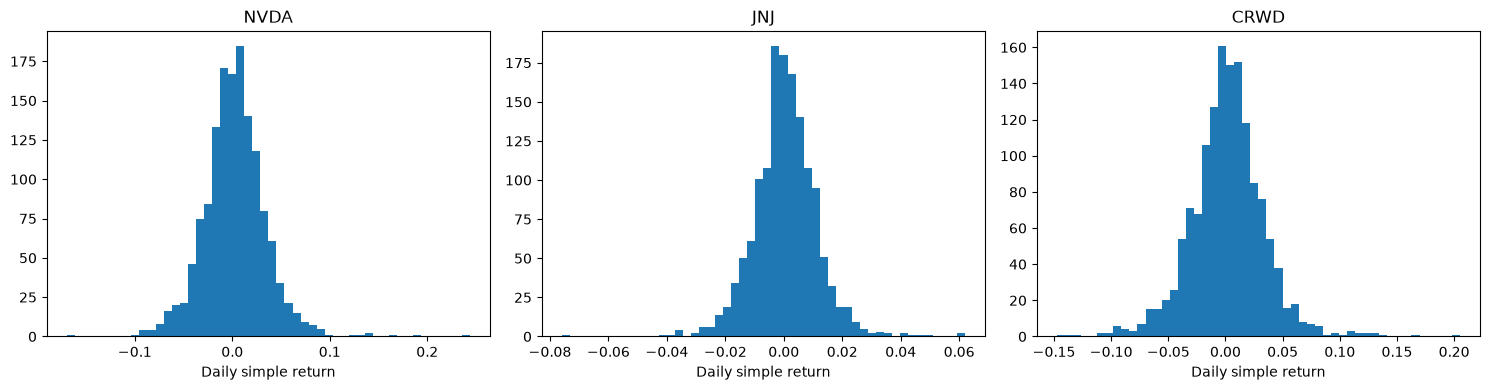

In [9]:
import matplotlib.pyplot as plt
selected = ["NVDA", "JNJ", "CRWD"]

fig, axes = plt.subplots(1, len(selected), figsize=(15, 4))
for ax, ticker in zip(axes, selected):
    data = df_simple[df_simple["ticker"] == ticker]["return"].dropna()
    ax.hist(data, bins=50)
    ax.set_title(ticker)
    ax.set_xlabel("Daily simple return")

plt.tight_layout()
plt.savefig("../reports/return_distributions.png")
plt.show()

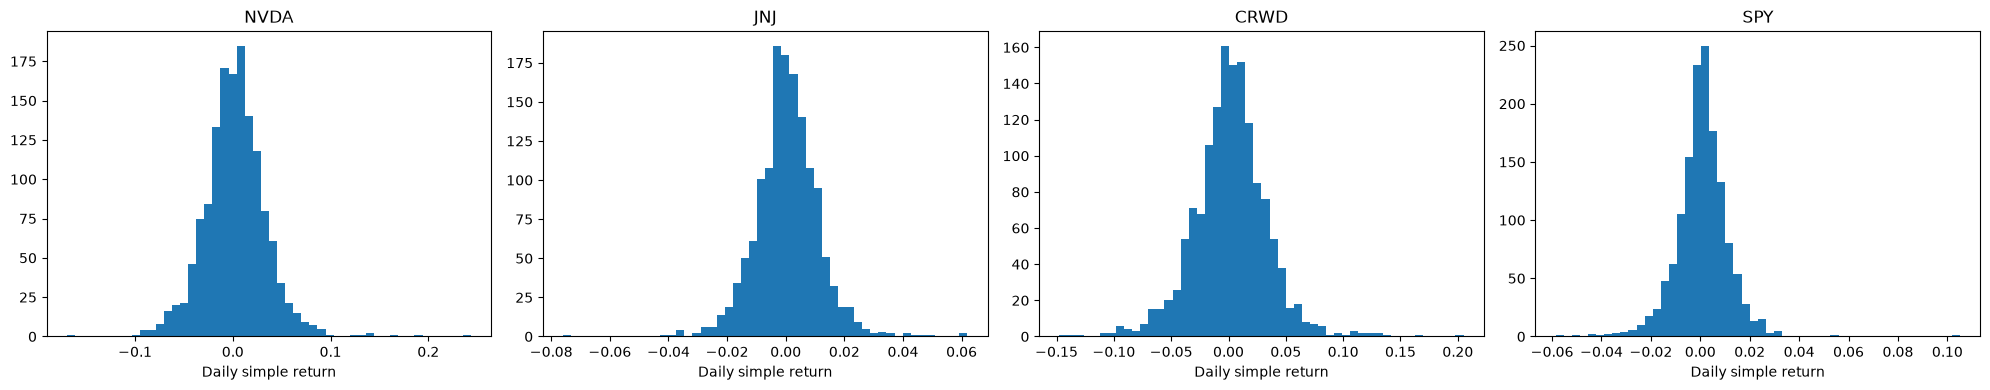

In [10]:
spy_df = load_ohlcv(["SPY"], start="2021-01-01", end=str(date.today()))
spy_simple = compute_returns(spy_df, method="simple")

selected = ["NVDA", "JNJ", "CRWD", "SPY"]
combined = pd.concat([df_simple, spy_simple], ignore_index=True)

fig, axes = plt.subplots(1, len(selected), figsize=(20, 4))
for ax, ticker in zip(axes, selected):
    data = combined[combined["ticker"] == ticker]["return"].dropna()
    ax.hist(data, bins=50)
    ax.set_title(ticker)
    ax.set_xlabel("Daily simple return")

plt.tight_layout()
plt.savefig("../reports/return_distributions.png")
plt.show()

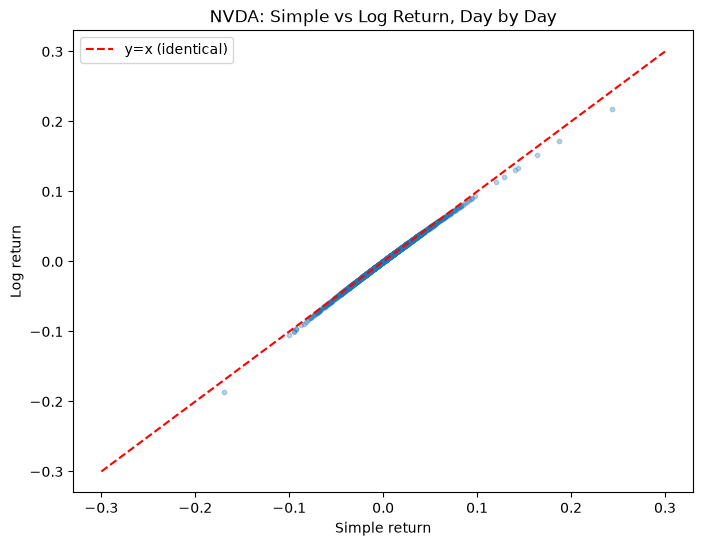

In [11]:
nvda_simple = df_simple[df_simple['ticker']=='NVDA'][['date','return']].rename(columns={'return':'simple_return'})
nvda_log = df_log[df_log['ticker']=='NVDA'][['date','return']].rename(columns={'return':'log_return'})
nvda_compare = nvda_simple.merge(nvda_log, on='date') 
plt.figure(figsize=(8,6))
plt.scatter(nvda_compare['simple_return'], nvda_compare['log_return'], alpha=0.3, s=10)
plt.plot([-0.3,0.3],[-0.3,0.3], color='red', linestyle='--', label='y=x (identical)') 
plt.xlabel('Simple return')
plt.ylabel('Log return') 
plt.title('NVDA: Simple vs Log Return, Day by Day') 
plt.legend()
plt.savefig('../reports/simple_vs_log_scatter.png') 
plt.show()

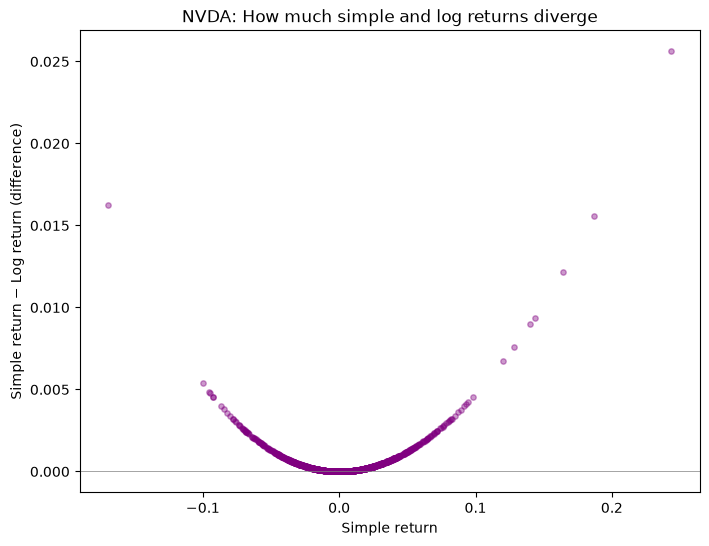

In [12]:
nvda_compare['diff'] = nvda_compare['simple_return'] - nvda_compare['log_return'] 
plt.figure(figsize=(8,6)) 
plt.scatter(nvda_compare['simple_return'], nvda_compare['diff'], alpha=0.4, s=15, color='purple') 
plt.xlabel('Simple return') 
plt.ylabel('Simple return − Log return (difference)') 
plt.title('NVDA: How much simple and log returns diverge') 
plt.axhline(0, color='gray', linewidth=0.5) 
plt.savefig('../reports/nvda_divergence.png') 
plt.show()

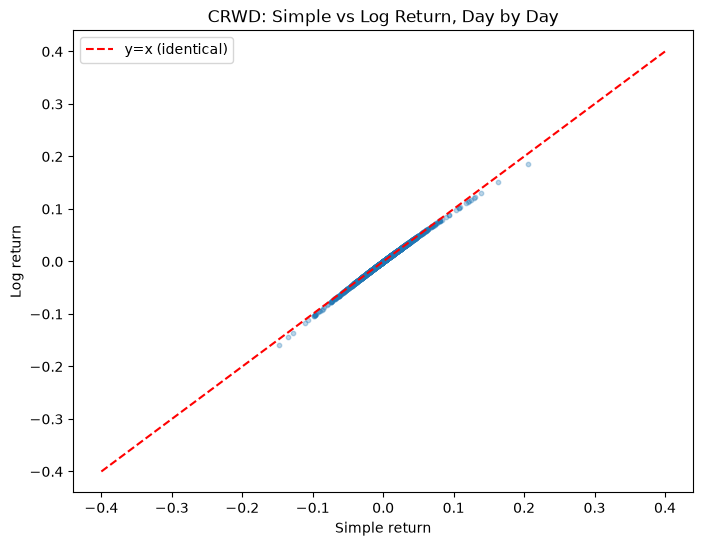

In [13]:
crwd_simple = df_simple[df_simple['ticker']=='CRWD'][['date','return']].rename(columns={'return':'simple_return'}) 
crwd_log = df_log[df_log['ticker']=='CRWD'][['date','return']].rename(columns={'return':'log_return'}) 
crwd_compare = crwd_simple.merge(crwd_log, on='date') 
plt.figure(figsize=(8,6)) 
plt.scatter(crwd_compare['simple_return'], crwd_compare['log_return'], alpha=0.3, s=10) 
plt.plot([-0.4,0.4],[-0.4,0.4], color='red', linestyle='--', label='y=x (identical)') 
plt.xlabel('Simple return') 
plt.ylabel('Log return') 
plt.title('CRWD: Simple vs Log Return, Day by Day') 
plt.legend() 
plt.savefig('../reports/crwd_simple_vs_log_scatter.png') 
plt.show()

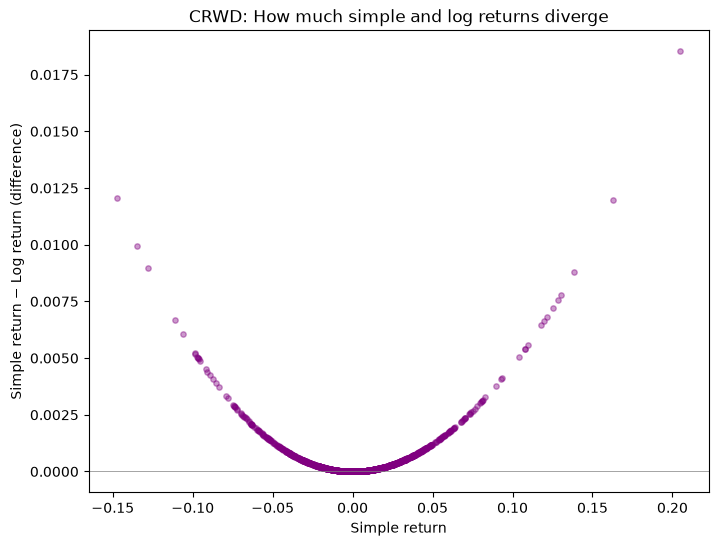

In [14]:
crwd_compare['diff'] = crwd_compare['simple_return'] - crwd_compare['log_return'] 
plt.figure(figsize=(8,6)) 
plt.scatter(crwd_compare['simple_return'], crwd_compare['diff'], alpha=0.4, s=15, color='purple') 
plt.xlabel('Simple return') 
plt.ylabel('Simple return − Log return (difference)') 
plt.title('CRWD: How much simple and log returns diverge') 
plt.axhline(0, color='gray', linewidth=0.5) 
plt.savefig('../reports/crwd_divergence.png') 
plt.show()

do log vs simple return 

In [15]:
market_caps = {}
for t in tickers:
    try:
        info = yf.Ticker(t).info
        market_caps[t] = info.get("marketCap", np.nan)
    except Exception:
        market_caps[t] = np.nan

market_caps = pd.Series(market_caps).dropna()
weights = market_caps / market_caps.sum()
weights.sort_values(ascending=False).head(10)

test_info = yf.Ticker("AAPL").info 
test_info.get("marketCap")

4925244309504

In [16]:
weights.sort_values(ascending=False).head(10)

NVDA     0.124048
AAPL     0.111014
GOOGL    0.095136
MSFT     0.084166
AMZN     0.060985
TSM      0.052347
META     0.043566
AVGO     0.038475
TSLA     0.034198
MU       0.027680
dtype: float64

In [17]:
len(market_caps)

50

In [18]:
df_rolling = rolling_stats(df_simple, window=21) 
eq_port = build_equal_weight_portfolio(df_simple) 
vw_port = build_value_weight_portfolio(df_simple, weights.to_dict()) 
eq_summary = performance_summary(eq_port['portfolio_return']) 
vw_summary = performance_summary(vw_port['portfolio_return']) 
print('Equal-weight:', eq_summary) 
print('Value-weight:', vw_summary)


Equal-weight: {'annualized_return': np.float64(0.2497890631657774), 'annualized_volatility': np.float64(0.19223942533803753), 'sharpe_ratio': np.float64(1.2993643875419596), 'max_drawdown': np.float64(-0.28784054464744024)}
Value-weight: {'annualized_return': np.float64(0.3067949865744823), 'annualized_volatility': np.float64(0.24088030875999097), 'sharpe_ratio': np.float64(1.2736407892941035), 'max_drawdown': np.float64(-0.3659919632823049)}


In [19]:
shares_hist = {}
for t in tickers:
    try:
        s = yf.Ticker(t).get_shares_full(start="2021-01-01", end=str(date.today()))
        shares_hist[t] = s
    except Exception:
        shares_hist[t] = None

# quick check on NVDA (had a 10-for-1 split in 2024, good test case)
print(shares_hist['NVDA'].head())
print(shares_hist['NVDA'].tail())

2021-02-02 00:00:00-05:00    607438016
2021-02-03 00:00:00-05:00    619000000
2021-03-03 00:00:00-05:00    620000000
2021-03-17 00:00:00-04:00    620000000
2021-03-24 00:00:00-04:00    625478976
dtype: int64
2025-12-03 00:00:00-05:00    24347000000
2026-02-28 00:00:00-05:00    24305000000
2026-05-13 00:00:00-04:00    24220525225
2026-05-21 00:00:00-04:00    24221000000
2026-08-28 00:00:00-04:00    24147000000
dtype: int64


In [20]:
eq_port = build_equal_weight_portfolio(df_simple)
vw_port_historic = build_value_weight_portfolio_historic(df_simple, shares_hist) 

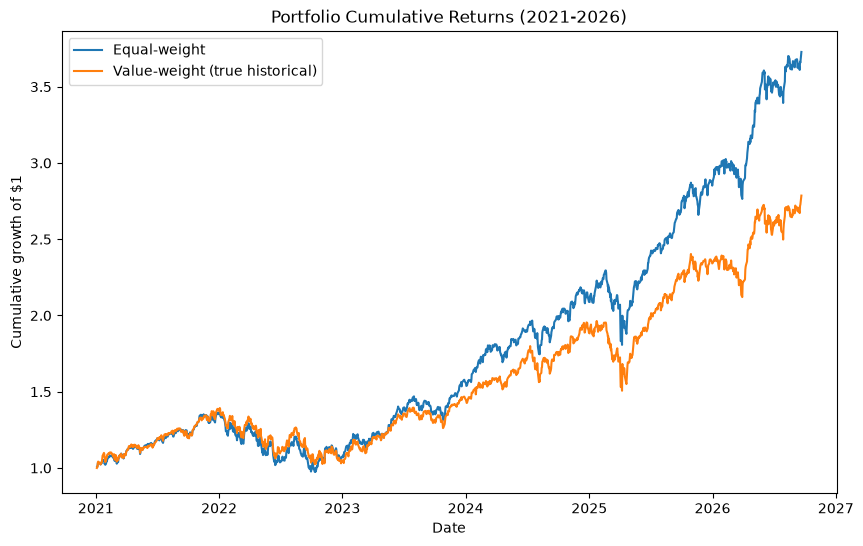

In [21]:
# Cumulative returns
eq_port['cumulative'] = (1 + eq_port['portfolio_return']).cumprod()
vw_port_historic['cumulative'] = (1 + vw_port_historic['portfolio_return']).cumprod()

plt.figure(figsize=(10,6))
plt.plot(eq_port['date'], eq_port['cumulative'], label='Equal-weight')
plt.plot(vw_port_historic['date'], vw_port_historic['cumulative'], label='Value-weight (true historical)')
plt.xlabel('Date')
plt.ylabel('Cumulative growth of $1')
plt.title('Portfolio Cumulative Returns (2021-2026)')
plt.legend()
plt.savefig('../reports/cumulative_returns.png')
plt.show()

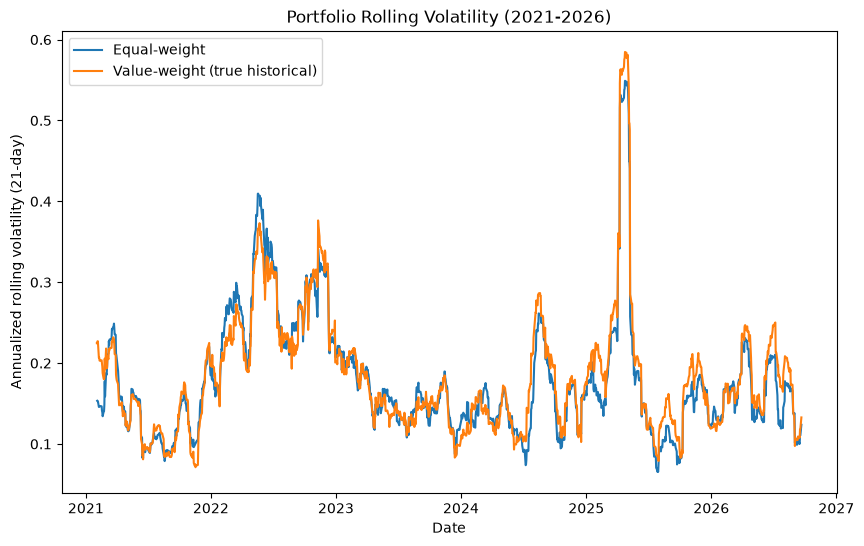

In [ ]:
# Rolling volatility
eq_port['rolling_vol'] = eq_port['portfolio_return'].rolling(21).std() * np.sqrt(252)
vw_port_historic['rolling_vol'] = vw_port_historic['portfolio_return'].rolling(21).std() * np.sqrt(252)

plt.figure(figsize=(10,6))
plt.plot(eq_port['date'], eq_port['rolling_vol'], label='Equal-weight')
plt.plot(vw_port_historic['date'], vw_port_historic['rolling_vol'], label='Value-weight (true historical)')
plt.xlabel('Date')
plt.ylabel('Annualized rolling volatility (21-day)')
plt.title('Portfolio Rolling Volatility (2021-2026)')
plt.legend()
plt.savefig('../reports/rolling_volatility.png')
plt.show()
'''we used a 21-trading-day window, approximating one calendar month,
 as our default lookback for rolling statistics
 '''

In [23]:
df_rolling.columns.tolist()

['date',
 'ticker',
 'open',
 'high',
 'low',
 'close',
 'adj_close',
 'volume',
 'return',
 'roll_mean',
 'roll_vol',
 'roll_skew',
 'roll_kurt']